# SB3 DQN — Results Analysis

This notebook analyses training and evaluation results for the SB3 DQN baseline across all seeds.

**Sections:**
1. Training curves (reward, episode length per seed)
2. Cross-seed comparison
3. Evaluation metrics (200 deterministic episodes)
4. Failure case analysis — deterministic evaluation
5. Crash timing over training
6. Seed 3 deep dive — policy collapse analysis


In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd()
if HERE.name in ("stablebaseline", "src"):
    ROOT = HERE.parent if HERE.name == "stablebaseline" else HERE.parent
    ROOT = HERE.parent.parent if HERE.name == "stablebaseline" else HERE.parent
    os.chdir(ROOT)
    HERE = ROOT

RESULTS_DIR = HERE / "results" / "sb3_dqn"
seed_dirs = sorted(RESULTS_DIR.glob("seed_*")) if RESULTS_DIR.exists() else []

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print(f"Seeds found: {[d.name for d in seed_dirs] or 'none'}")

Seeds found: ['seed_0', 'seed_1', 'seed_2', 'seed_3', 'seed_4', 'seed_5']


## 1. Training Curves

Smoothed episode reward and episode length over training steps for each seed.

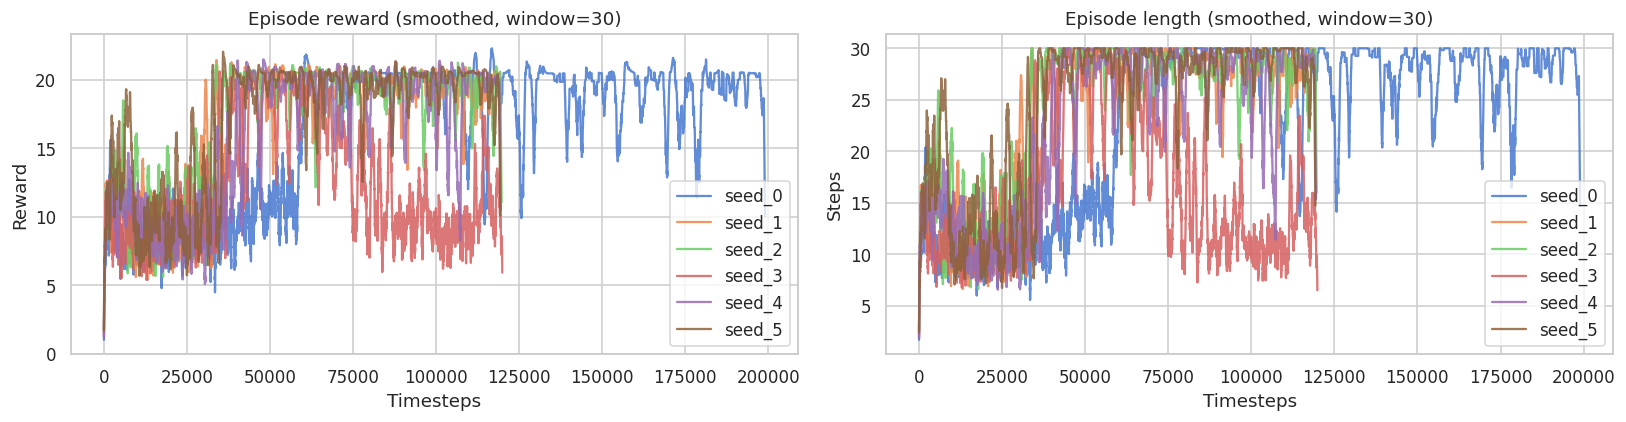

In [2]:
def load_monitor(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, skiprows=1)


def smooth(values: np.ndarray, window: int = 30) -> np.ndarray:
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="same")


if not seed_dirs:
    print("No results found.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    for seed_dir in seed_dirs:
        monitor_path = seed_dir / "monitor.monitor.csv"
        if not monitor_path.exists():
            continue
        df = load_monitor(monitor_path)
        df["cumsteps"] = df["l"].cumsum()
        label = seed_dir.name

        axes[0].plot(df["cumsteps"], smooth(df["r"].values), alpha=0.85, label=label)
        axes[1].plot(df["cumsteps"], smooth(df["l"].values), alpha=0.85, label=label)

    axes[0].set_title("Episode reward (smoothed, window=30)")
    axes[0].set_xlabel("Timesteps")
    axes[0].set_ylabel("Reward")
    axes[0].legend()

    axes[1].set_title("Episode length (smoothed, window=30)")
    axes[1].set_xlabel("Timesteps")
    axes[1].set_ylabel("Steps")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 2. Cross-Seed Comparison

Mean ± std reward across seeds at each timestep bin.

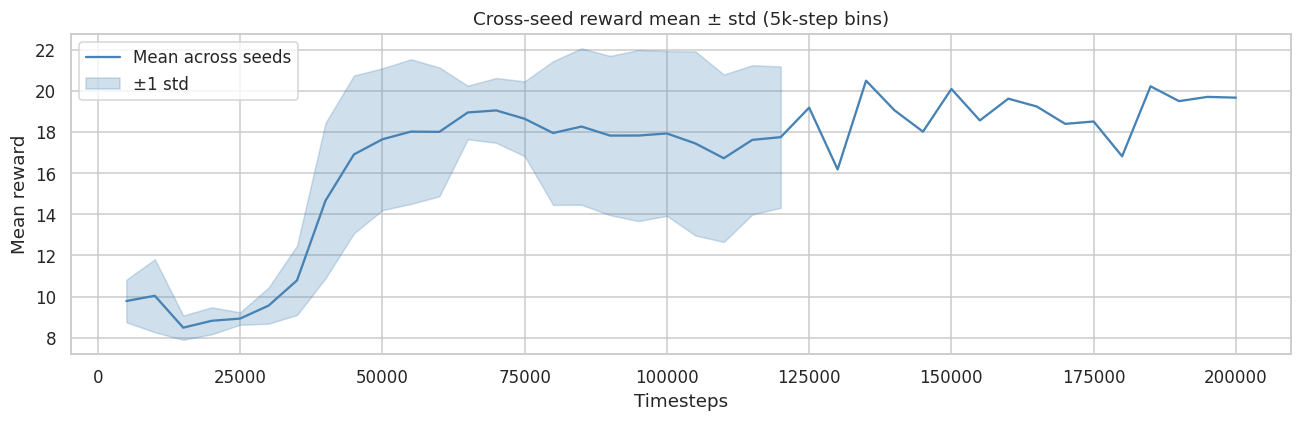

In [3]:
if seed_dirs:
    all_dfs = []
    for seed_dir in seed_dirs:
        monitor_path = seed_dir / "monitor.monitor.csv"
        if not monitor_path.exists():
            continue
        df = load_monitor(monitor_path)
        df["cumsteps"] = df["l"].cumsum()
        df["seed"] = seed_dir.name
        all_dfs.append(df)

    all_data = pd.concat(all_dfs, ignore_index=True)
    max_steps = all_data["cumsteps"].max()
    bin_size = 5000
    bins = np.arange(0, max_steps + bin_size, bin_size)
    all_data["bin"] = pd.cut(all_data["cumsteps"], bins=bins).apply(
        lambda x: x.right if pd.notna(x) else np.nan,
    )

    agg = all_data.groupby(["bin", "seed"])["r"].mean().reset_index()
    cross = agg.groupby("bin")["r"].agg(["mean", "std"]).reset_index()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(cross["bin"], cross["mean"], color="steelblue", label="Mean across seeds")
    ax.fill_between(
        cross["bin"],
        cross["mean"] - cross["std"],
        cross["mean"] + cross["std"],
        alpha=0.25,
        color="steelblue",
        label="±1 std",
    )
    ax.set_title("Cross-seed reward mean ± std (5k-step bins)")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Mean reward")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 3. Evaluation Metrics

Final deterministic evaluation -- **200 episodes per seed**.
Generated by `evaluate_sb3_dqn.py`. Re-run to refresh:
```bash
for seed in 0 1 2 3 4 5; do
    uv run python src/stablebaseline/evaluate_sb3_dqn.py --model-path results/sb3_dqn/seed_${seed}/final_model.zip
done
```

> **Note:** seed_3 is expected to be a strong outlier (policy collapse -- see Section 6).

In [4]:
eval_results = []
for seed_dir in seed_dirs:
    for candidate in [
        seed_dir / "eval_results.json",
        seed_dir / "final_model" / "eval_results.json",
    ]:
        if candidate.exists():
            with open(candidate) as f:
                r = json.load(f)
                r.setdefault("seed", seed_dir.name)
                eval_results.append(r)
            break

if eval_results:
    df_eval = pd.DataFrame(eval_results)
    df_eval["outlier"] = df_eval["crash_rate"] > 0.5
    cols = [
        "seed",
        "mean_reward",
        "std_reward",
        "crash_rate",
        "offroad_rate",
        "mean_speed",
        "mean_episode_length",
    ]
    cols = [c for c in cols if c in df_eval.columns]
    print("=== Per-seed evaluation results ===")
    print(df_eval[cols].round(3).to_string(index=False))

    df_healthy = df_eval[~df_eval["outlier"]]
    numeric_cols = [c for c in cols if c not in ("seed", "model_path")]

    print("\n=== Aggregate -- ALL seeds ===")
    for col in numeric_cols:
        vals = df_eval[col].dropna()
        print(f"  {col:25s}: {vals.mean():.3f} +/- {vals.std():.3f}")

    print("\n=== Aggregate -- excluding seed_3 (collapsed) ===")
    for col in numeric_cols:
        vals = df_healthy[col].dropna()
        print(f"  {col:25s}: {vals.mean():.3f} +/- {vals.std():.3f}")
else:
    print("No eval_results.json found. Run evaluate_sb3_dqn.py for each seed first.")

=== Per-seed evaluation results ===
 seed  mean_reward  std_reward  crash_rate  offroad_rate  mean_speed  mean_episode_length
    0       20.199       1.672       0.030           0.0      20.021               29.655
    1       20.322       1.395       0.010           0.0      20.030               29.815
    2       20.049       2.657       0.035           0.0      20.119               29.350
    3       13.450       6.586       0.965           0.0      25.051               16.970
    4       20.322       1.395       0.010           0.0      20.029               29.815
    5       19.989       2.815       0.045           0.0      20.117               29.250

=== Aggregate -- ALL seeds ===
  mean_reward              : 19.055 +/- 2.749
  std_reward               : 2.753 +/- 1.978
  crash_rate               : 0.182 +/- 0.384
  offroad_rate             : 0.000 +/- 0.000
  mean_speed               : 20.895 +/- 2.037
  mean_episode_length      : 27.476 +/- 5.152

=== Aggregate -- excluding s

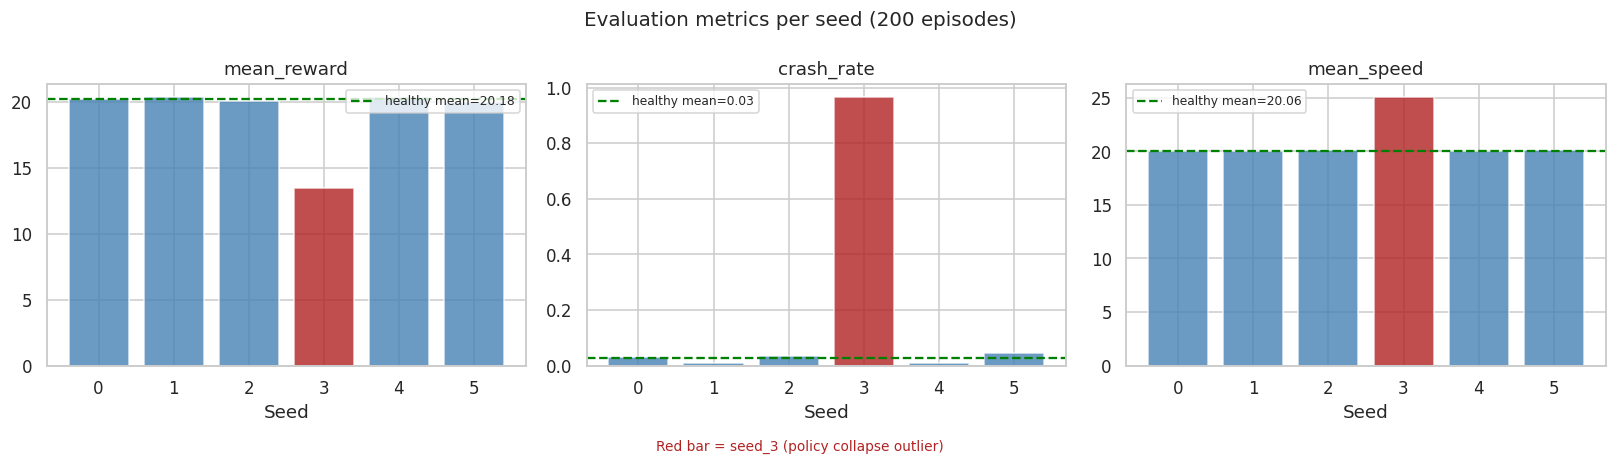

In [5]:
if eval_results:
    metrics = ["mean_reward", "crash_rate", "mean_speed"]
    metrics = [m for m in metrics if m in df_eval.columns]
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))
    if len(metrics) == 1:
        axes = [axes]

    colors = ["firebrick" if o else "steelblue" for o in df_eval["outlier"]]

    for ax, metric in zip(axes, metrics):
        vals = df_eval[metric].dropna()
        ax.bar(range(len(vals)), vals, color=colors, alpha=0.8)
        healthy_mean = df_healthy[metric].mean()
        ax.axhline(
            healthy_mean,
            color="green",
            linestyle="--",
            linewidth=1.5,
            label=f"healthy mean={healthy_mean:.2f}",
        )
        ax.set_title(metric)
        ax.set_xlabel("Seed")
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(df_eval["seed"].tolist())
        ax.legend(fontsize=8)

    fig.text(
        0.5,
        -0.02,
        "Red bar = seed_3 (policy collapse outlier)",
        ha="center",
        fontsize=9,
        color="firebrick",
    )
    plt.suptitle("Evaluation metrics per seed (200 episodes)", fontsize=13)
    plt.tight_layout()
    plt.show()

### Interpretation -- Evaluation Metrics

**Seeds 0, 1, 2, 4, 5** converged consistently:
- Mean reward: **~20.2 +/- 0.15** (excluding seed_3)
- Crash rate: **2.6%** on average -- the agent learned to drive safely at high speed
- Speed ~20 m/s confirms the agent adopted the high-speed strategy rewarded by the environment

**Seed_3** is a clear outlier -- **96.5% crash rate**, reward 13.5 -- due to a policy collapse during training (see Section 6).
The `final_model.zip` for seed_3 captures the degraded end-of-training policy, not the peak policy.
This underlines the importance of using `best_model/` checkpoints in addition to final models.


## 4. Failure Case Analysis (Deterministic Evaluation)

Episode category breakdown from **200 deterministic evaluation episodes** per seed.
Loaded from `eval_episodes.json` (generated by `evaluate_sb3_dqn.py`).
Run evaluations first if files are missing:
```bash
for seed in 0 1 2 3 4 5; do
    uv run python src/stablebaseline/evaluate_sb3_dqn.py --model-path results/sb3_dqn/seed_${seed}/final_model.zip
done
```

In [6]:
def classify_episode_det(ep: dict) -> str:
    if ep["length"] <= 3 or ep["crashed"]:
        if ep["length"] <= 3:
            return "early crash"
        return "crash"
    r = ep["reward"]
    if r < 5:
        return "crash / severe failure"
    if r < 15:
        return "poor survival"
    if r < 25:
        return "medium performance"
    return "good performance"


det_summary_rows = []
missing_seeds = []
for seed_dir in seed_dirs:
    ep_path = seed_dir / "eval_episodes.json"
    if not ep_path.exists():
        missing_seeds.append(seed_dir.name)
        continue
    with open(ep_path) as f:
        episodes = json.load(f)
    n = len(episodes)
    counts = {}
    for ep in episodes:
        cat = classify_episode_det(ep)
        counts[cat] = counts.get(cat, 0) + 1
    row = {k: v / n * 100 for k, v in counts.items()}
    row["seed"] = seed_dir.name
    row["n_episodes"] = n
    det_summary_rows.append(row)

if missing_seeds:
    print(f"Missing eval_episodes.json for: {missing_seeds}")
    print("Run evaluate_sb3_dqn.py for those seeds first.")

if det_summary_rows:
    cat_order = [
        "early crash",
        "crash",
        "crash / severe failure",
        "poor survival",
        "medium performance",
        "good performance",
    ]
    df_det = pd.DataFrame(det_summary_rows).set_index("seed").fillna(0)
    cols_present = [c for c in cat_order if c in df_det.columns]
    df_det = df_det[cols_present].round(1)
    print(
        f"Episode category distribution — deterministic eval ({det_summary_rows[0]['n_episodes']} eps/seed):",
    )
    print(df_det.to_string())

Episode category distribution — deterministic eval (200 eps/seed):
        early crash  crash  medium performance  good performance
seed                                                            
seed_0          0.0    3.0                97.0               0.0
seed_1          0.0    1.0                99.0               0.0
seed_2          0.0    3.5                96.5               0.0
seed_3          3.0   93.5                 0.0               3.5
seed_4          0.0    1.0                99.0               0.0
seed_5          0.5    4.0                95.5               0.0


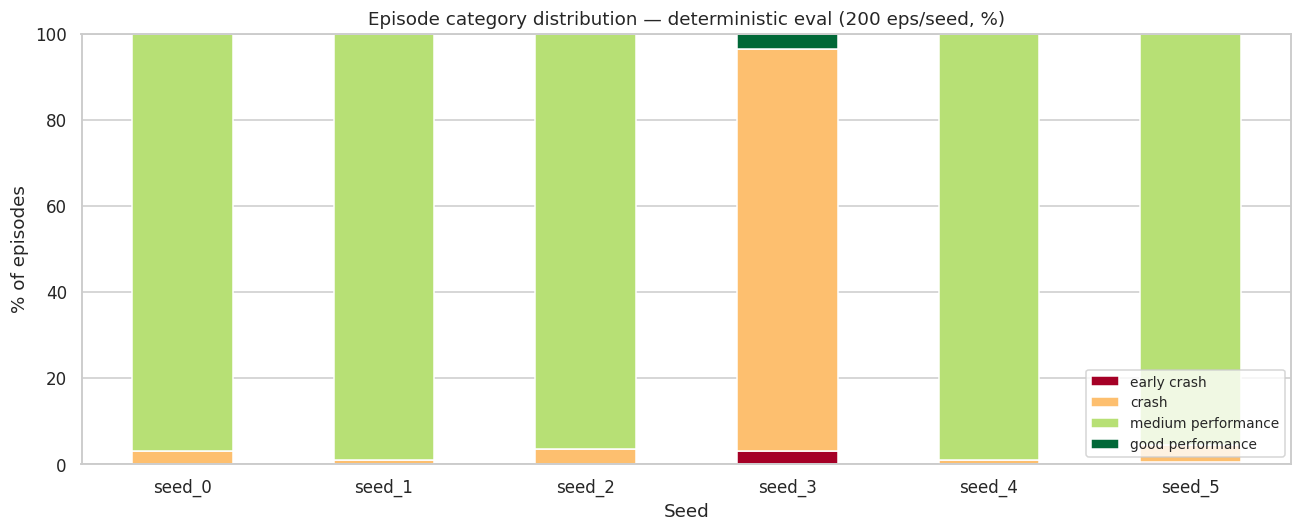

In [7]:
if det_summary_rows:
    df_det.plot(
        kind="bar",
        stacked=True,
        figsize=(12, 5),
        colormap="RdYlGn",
        edgecolor="white",
    )
    plt.title(
        f"Episode category distribution — deterministic eval ({det_summary_rows[0]['n_episodes']} eps/seed, %)",
    )
    plt.xlabel("Seed")
    plt.ylabel("% of episodes")
    plt.xticks(rotation=0)
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.show()

### Interpretation -- Failure Case Analysis

Based on 200 deterministic evaluation episodes per seed (final policy):

- **Seeds 0-2, 4-5**: very low crash rates (1-4.5%), with the vast majority of episodes in *medium/good performance* range. The agent learned to drive at high speed while avoiding collisions. The near-absence of *good performance* (reward > 25) reflects the `lane_change_penalty = -0.02` discouraging active maneuvering -- the agent prefers straight, fast driving.

- **Seed_3**: dominated by crashes -- policy collapsed after a destabilizing target network update (~60-70k steps). With only 120k training steps, the agent never recovered. Seeds trained to 200k were more robust.


## 5. Crash Timing Analysis

When during training did crashes occur? Crash rate over timesteps.

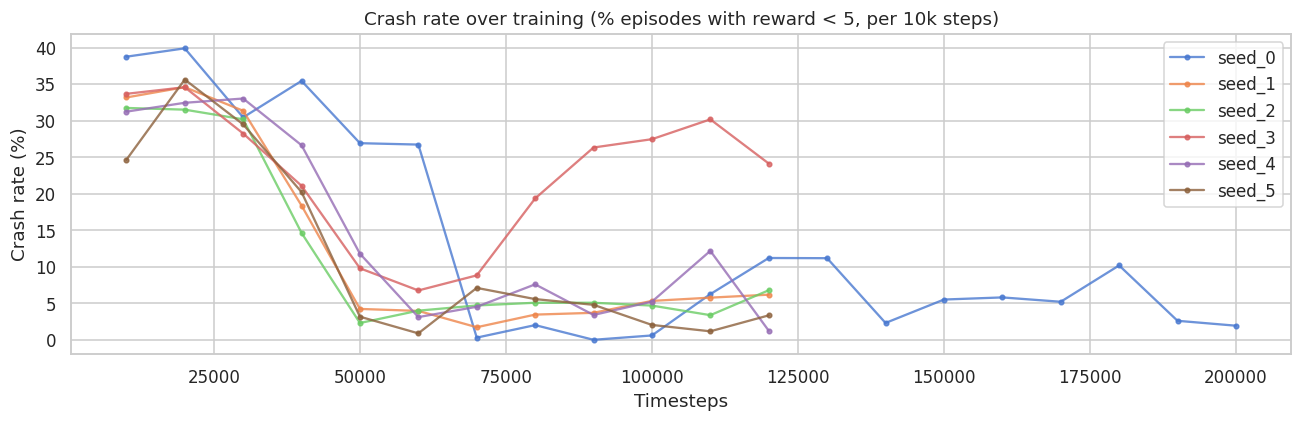

In [8]:
if seed_dirs:
    fig, ax = plt.subplots(figsize=(12, 4))

    for seed_dir in seed_dirs:
        monitor_path = seed_dir / "monitor.monitor.csv"
        if not monitor_path.exists():
            continue
        df = load_monitor(monitor_path)
        df["cumsteps"] = df["l"].cumsum()
        df["is_crash"] = (df["r"] < 5).astype(float)

        bin_size = 10_000
        max_steps = df["cumsteps"].max()
        bins = np.arange(0, max_steps + bin_size, bin_size)
        df["bin"] = pd.cut(df["cumsteps"], bins=bins).apply(
            lambda x: x.right if pd.notna(x) else np.nan,
        )
        crash_rate = df.groupby("bin")["is_crash"].mean()

        ax.plot(
            crash_rate.index,
            crash_rate.values * 100,
            marker="o",
            markersize=3,
            alpha=0.8,
            label=seed_dir.name,
        )

    ax.set_title("Crash rate over training (% episodes with reward < 5, per 10k steps)")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Crash rate (%)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Seed 3 Deep Dive -- Policy Collapse

Seed_3 trained for only 120k steps and ended with 96.5% crash rate -- far below every other seed.
Let s show why: the training reward peaked around 55-60k steps then collapsed catastrophically.


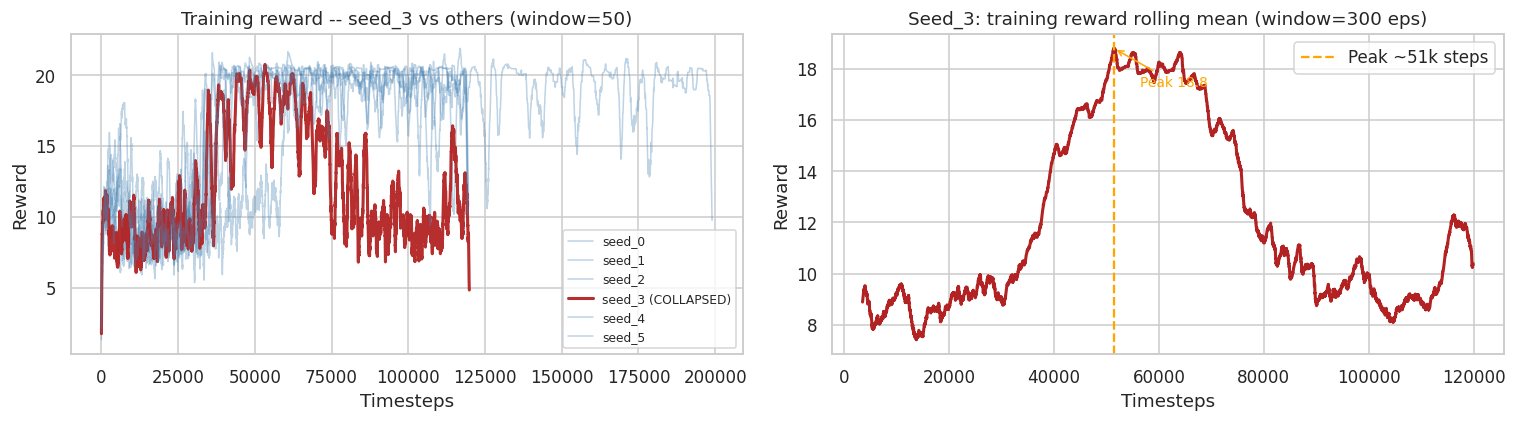

In [9]:
# Deep dive: seed_3 training trajectory vs healthy seeds
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for seed_dir in seed_dirs:
    monitor_path = seed_dir / "monitor.monitor.csv"
    if not monitor_path.exists():
        continue
    df = load_monitor(monitor_path)
    df["cumsteps"] = df["l"].cumsum()
    is_collapsed = seed_dir.name == "seed_3"
    color = "firebrick" if is_collapsed else "steelblue"
    alpha = 0.95 if is_collapsed else 0.35
    lw = 2.0 if is_collapsed else 1.0
    label = f"{seed_dir.name} (COLLAPSED)" if is_collapsed else seed_dir.name
    axes[0].plot(
        df["cumsteps"],
        smooth(df["r"].values, 50),
        color=color,
        alpha=alpha,
        lw=lw,
        label=label,
    )

axes[0].set_title("Training reward -- seed_3 vs others (window=50)")
axes[0].set_xlabel("Timesteps")
axes[0].set_ylabel("Reward")
axes[0].legend(fontsize=8)

seed3_dir = next(d for d in seed_dirs if d.name == "seed_3")
df3 = load_monitor(seed3_dir / "monitor.monitor.csv")
df3["cumsteps"] = df3["l"].cumsum()
roll = df3["r"].rolling(300).mean()
axes[1].plot(df3["cumsteps"], roll, color="firebrick", lw=2)
peak_idx = roll.idxmax()
peak_step = int(df3.loc[peak_idx, "cumsteps"])
peak_val = float(roll[peak_idx])
axes[1].axvline(
    peak_step,
    color="orange",
    linestyle="--",
    label=f"Peak ~{peak_step // 1000}k steps",
)
axes[1].annotate(
    f"Peak {peak_val:.1f}",
    xy=(peak_step, peak_val),
    xytext=(peak_step + 5000, peak_val - 1.5),
    fontsize=9,
    arrowprops={"arrowstyle": "->", "color": "orange"},
    color="orange",
)
axes[1].set_title("Seed_3: training reward rolling mean (window=300 eps)")
axes[1].set_xlabel("Timesteps")
axes[1].set_ylabel("Reward")
axes[1].legend()
plt.tight_layout()
plt.show()

### Root Cause Analysis -- Seed_3 Policy Collapse

**What happened:**  
The training reward for seed_3 peaked around **55-60k steps** (~18 reward), then collapsed to ~9-10 and never recovered. By end of training (120k steps), the agent crashes in almost every episode.

**Most likely cause -- target network hard update instability:**  
DQN uses a *hard update* (`tau=1.0`, `target_update_interval=1000`): every 1000 gradient steps, the target network is fully replaced by the current network. If the current Q-network has overfitted a bad batch of transitions, the hard update propagates this corruption into the target, causing Q-value overestimation -> the policy becomes aggressive -> crashes explode -> the replay buffer fills with crash transitions -> a feedback loop prevents recovery.

**Why seed_3 specifically:**  
The random seed determines the initial network weights and the traffic scenario distribution during exploration. Seed_3 likely encountered a sequence of transitions that triggered Q-value divergence right after the peak. Seeds 0, 1, 2, 4, 5 either avoided this instability or recovered within their training budget.

**Why seed_0 is more robust:**  
Seed_0 trained for **200k steps** (vs 120k for seed_3). Even if a similar transient regression occurred, the longer budget allowed recovery -- consistent with the README observation of a transient regression at 105-115k steps in seed_0.
